<a href="https://colab.research.google.com/github/wasimciit/House-Price-Prediction/blob/main/House_price_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# House Price Prediction

In [ ]:
pip install optuna

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


DEPRECATION: Loading egg at c:\programdata\anaconda3\lib\site-packages\vboxapi-1.0-py3.11.egg is deprecated. pip 24.3 will enforce this behaviour change. A possible replacement is to use pip for package installation.. Discussion can be found at https://github.com/pypa/pip/issues/12330


In [ ]:
pip install catboost


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


DEPRECATION: Loading egg at c:\programdata\anaconda3\lib\site-packages\vboxapi-1.0-py3.11.egg is deprecated. pip 24.3 will enforce this behaviour change. A possible replacement is to use pip for package installation.. Discussion can be found at https://github.com/pypa/pip/issues/12330


In [ ]:
pip install lightgbm


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


DEPRECATION: Loading egg at c:\programdata\anaconda3\lib\site-packages\vboxapi-1.0-py3.11.egg is deprecated. pip 24.3 will enforce this behaviour change. A possible replacement is to use pip for package installation.. Discussion can be found at https://github.com/pypa/pip/issues/12330


In [ ]:
!pip install xgboost

Defaulting to user installation because normal site-packages is not writeable


DEPRECATION: Loading egg at c:\programdata\anaconda3\lib\site-packages\vboxapi-1.0-py3.11.egg is deprecated. pip 24.3 will enforce this behaviour change. A possible replacement is to use pip for package installation.. Discussion can be found at https://github.com/pypa/pip/issues/12330


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import optuna
from optuna.samplers import TPESampler

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.preprocessing import RobustScaler, PolynomialFeatures
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score

from catboost import CatBoostRegressor
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor
from sklearn.ensemble import StackingRegressor

In [ ]:
data = fetch_california_housing(as_frame=True)
df=data.frame
df['MedHouseVal'] = data.target

In [ ]:
print("Dataset shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

Dataset shape: (20640, 9)

Columns:
['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude', 'MedHouseVal']


In [ ]:
print("\n=== Info ===")
print(df.info())

print("\n=== Descriptive Statistics ===")
print(df.describe().round(2).T)

print("\n=== Missing Values ===")
print(df.isnull().sum())


=== Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB
None

=== Descriptive Statistics ===
               count     mean      std     min     25%      50%      75%  \
MedInc       20640.0     3.87     1.90    0.50    2.56     3.53     4.74   
HouseAge     20640.0    28.64    12.59    1.00   18.00    29.00    37.00   
AveRooms     20640.0     5.43     2.47    0.85    4.44     5.23     6.05   
AveBedrms    20640.0     1.10     0

In [ ]:
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("viridis")

c:\ProgramData\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


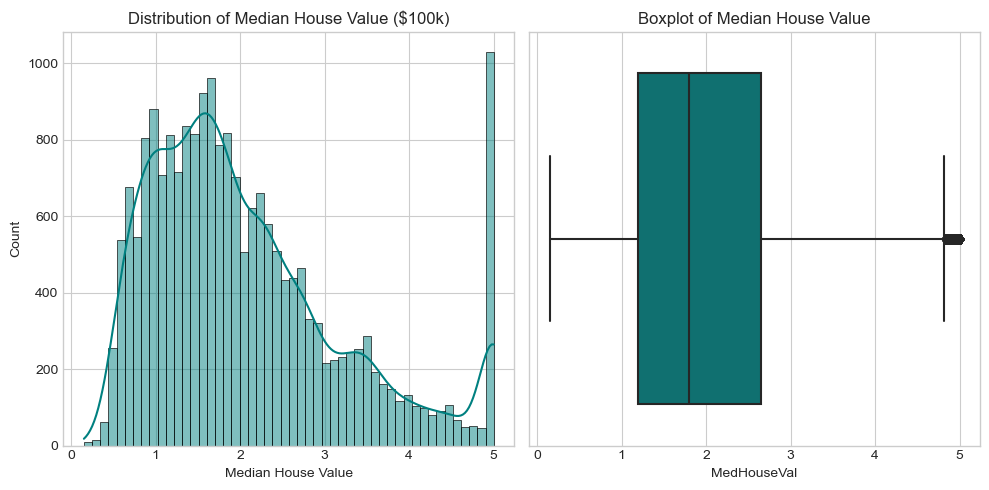

Target skewness: 0.978
Target has cap at 5 ($500,000) → 992 houses


In [ ]:
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
sns.histplot(df['MedHouseVal'], bins=50, kde=True, color='teal')
plt.title('Distribution of Median House Value ($100k)')
plt.xlabel('Median House Value')

plt.subplot(1, 2, 2)
sns.boxplot(x=df['MedHouseVal'], color='teal')
plt.title('Boxplot of Median House Value')

plt.tight_layout()
plt.show()

print("Target skewness:", df['MedHouseVal'].skew().round(3))
print("Target has cap at 5 ($500,000) →", (df['MedHouseVal'] >= 5).sum(), "houses")

c:\ProgramData\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\ProgramData\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\ProgramData\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\ProgramData\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating

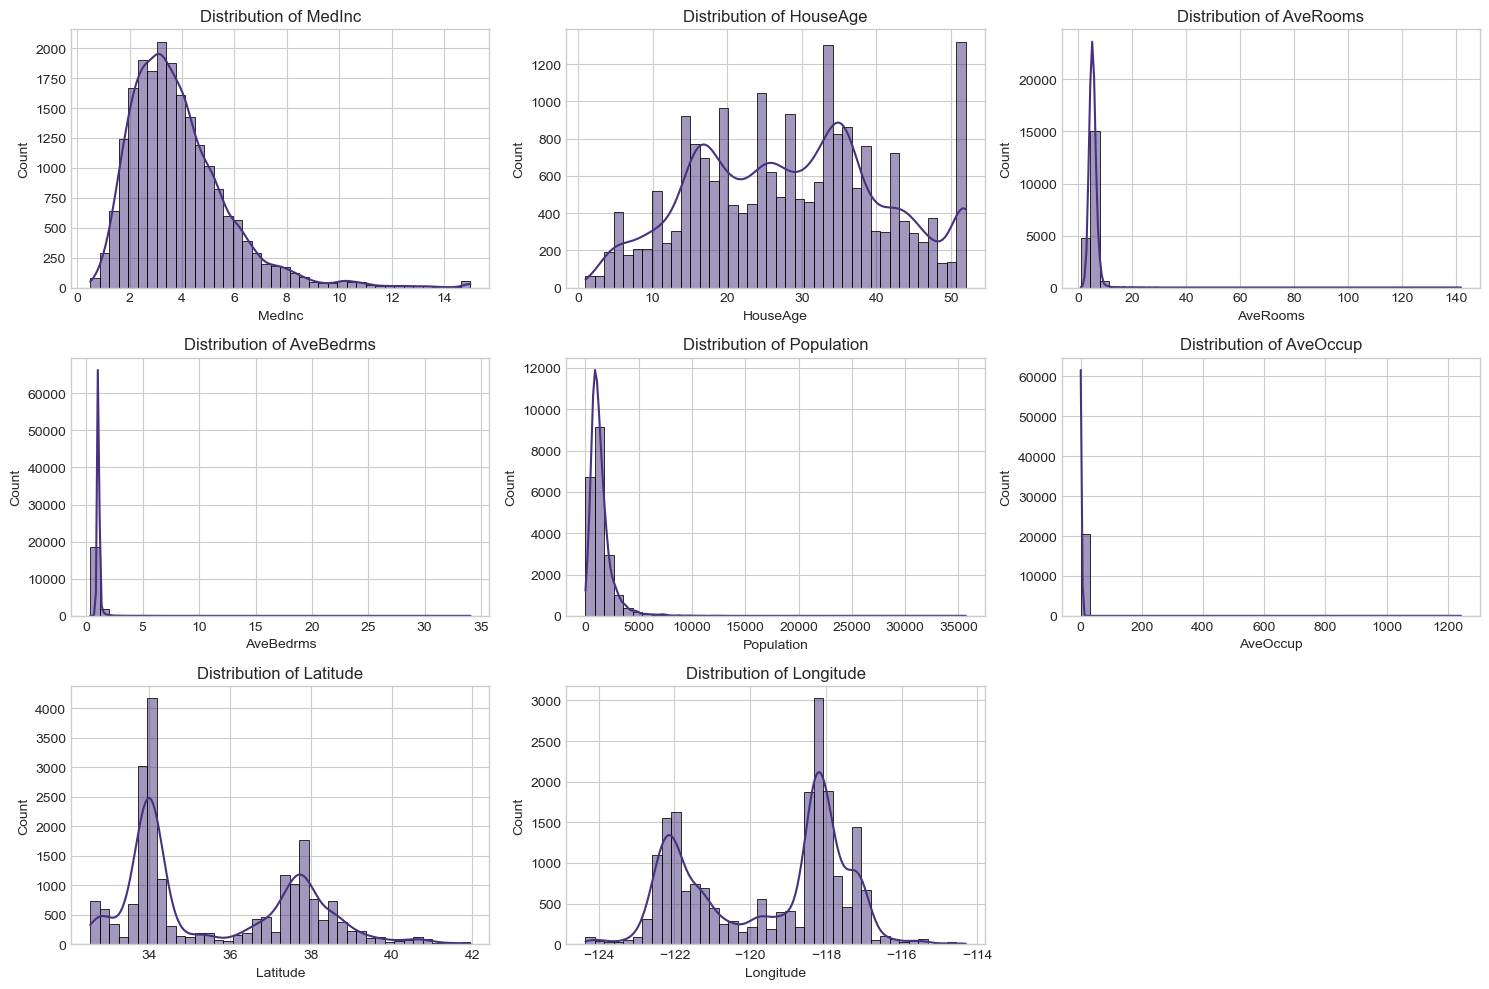

In [ ]:
features = ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms',
            'Population', 'AveOccup', 'Latitude', 'Longitude']

plt.figure(figsize=(15, 10))

for i, col in enumerate(features, 1):
    plt.subplot(3, 3, i)
    sns.histplot(df[col], bins=40, kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)

plt.tight_layout()
plt.show()

c:\ProgramData\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\ProgramData\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\ProgramData\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\ProgramData\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating

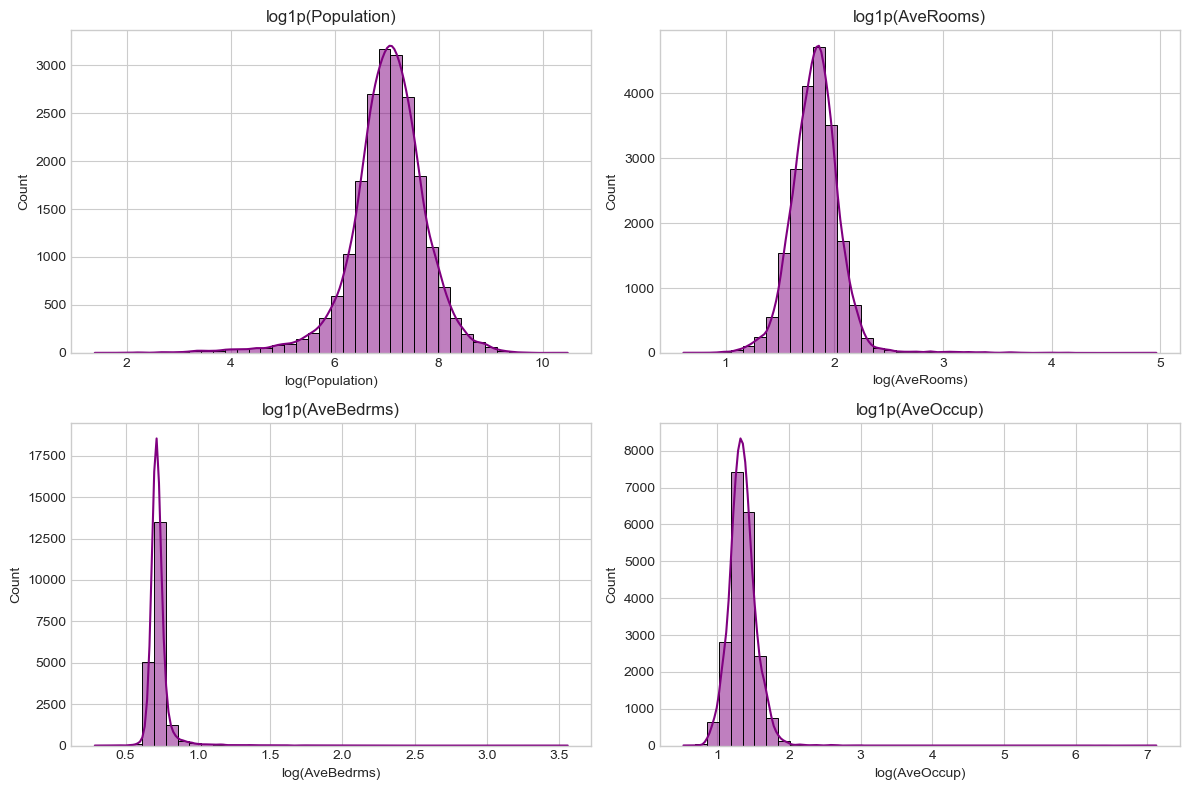

In [ ]:
skewed = ['Population', 'AveRooms', 'AveBedrms', 'AveOccup']
plt.figure(figsize=(12, 8))

for i, col in enumerate(skewed, 1):
    plt.subplot(2, 2, i)
    sns.histplot(np.log1p(df[col]), bins=40, kde=True, color='purple')
    plt.title(f'log1p({col})')
    plt.xlabel(f'log({col})')

plt.tight_layout()
plt.show()

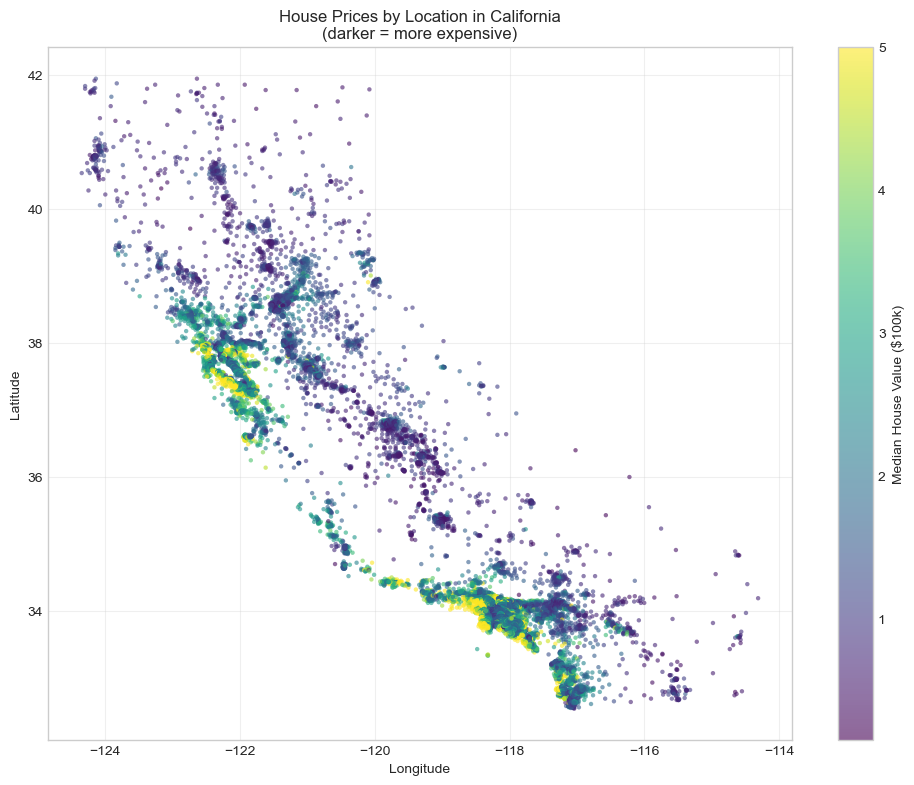

In [ ]:
plt.figure(figsize=(12, 9))

scatter = plt.scatter(df['Longitude'], df['Latitude'],
                     c=df['MedHouseVal'], cmap='viridis',
                     s=10, alpha=0.6, edgecolor='none')

plt.colorbar(scatter, label='Median House Value ($100k)')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('House Prices by Location in California\n(darker = more expensive)')
plt.grid(True, alpha=0.3)
plt.show()

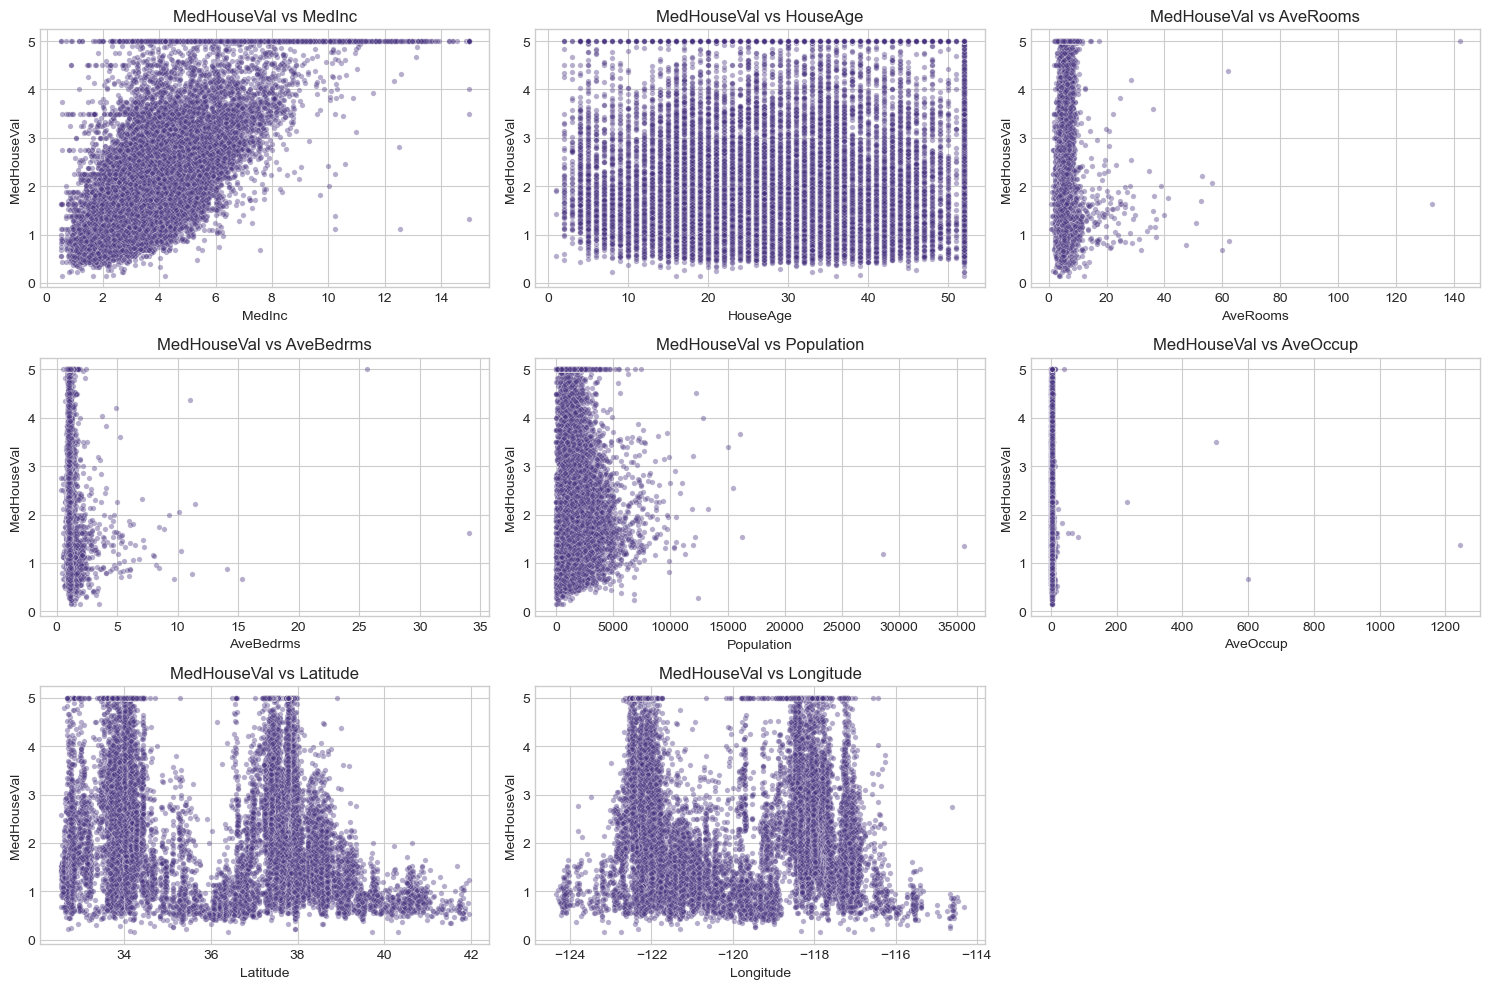

In [ ]:
plt.figure(figsize=(15, 10))

for i, col in enumerate(features, 1):
    plt.subplot(3, 3, i)
    sns.scatterplot(x=df[col], y=df['MedHouseVal'], alpha=0.4, s=15)
    plt.title(f'MedHouseVal vs {col}')

plt.tight_layout()
plt.show()

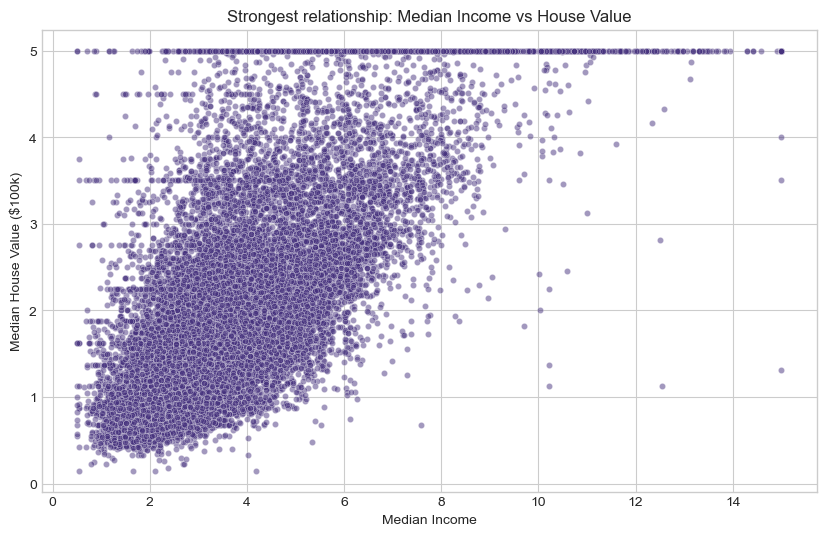

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=df['MedInc'], y=df['MedHouseVal'], alpha=0.5, s=20)
plt.title('Strongest relationship: Median Income vs House Value')
plt.xlabel('Median Income')
plt.ylabel('Median House Value ($100k)')
plt.show()

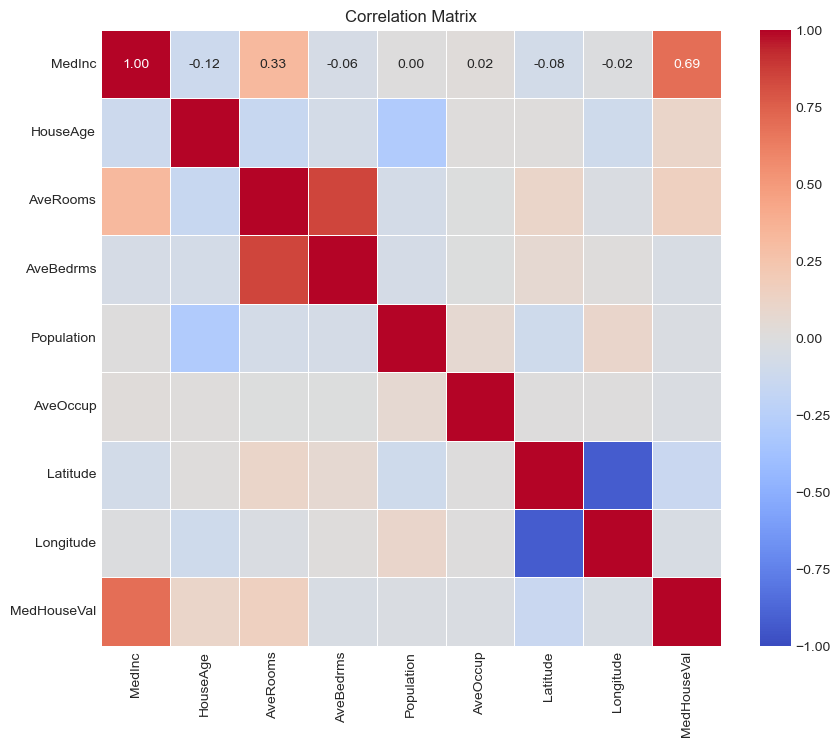

In [ ]:
plt.figure(figsize=(10, 8))
corr = df.corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            vmin=-1, vmax=1, linewidths=0.5)
plt.title('Correlation Matrix')
plt.show()

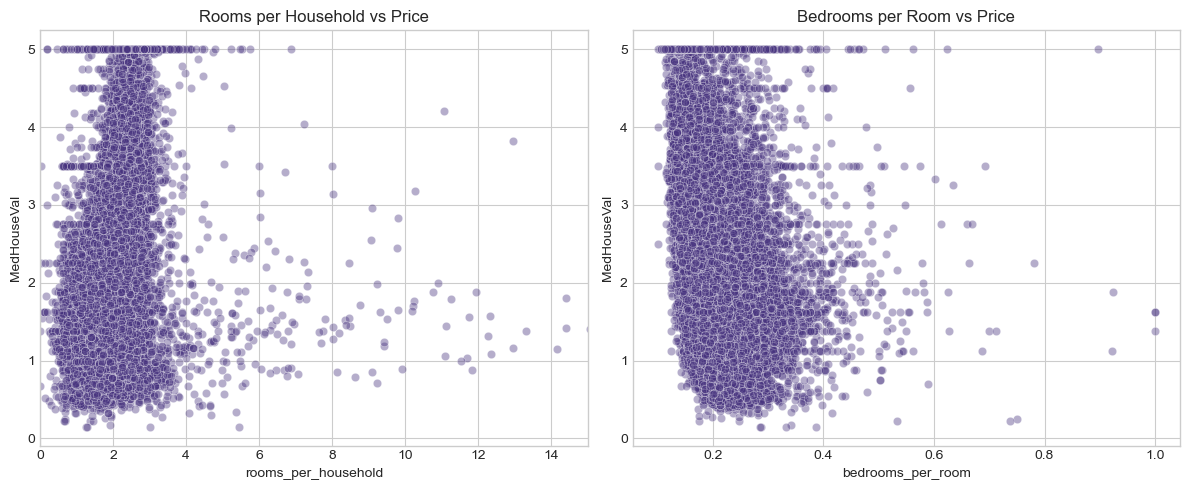

In [ ]:
df['rooms_per_household'] = df['AveRooms'] / df['AveOccup']
df['bedrooms_per_room']   = df['AveBedrms'] / df['AveRooms']

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.scatterplot(x=df['rooms_per_household'], y=df['MedHouseVal'], alpha=0.4)
plt.title('Rooms per Household vs Price')
plt.xlim(0, 15)  # many extreme outliers

plt.subplot(1, 2, 2)
sns.scatterplot(x=df['bedrooms_per_room'], y=df['MedHouseVal'], alpha=0.4)
plt.title('Bedrooms per Room vs Price')

plt.tight_layout()
plt.show()

In [ ]:
print("\n=== Extreme / Suspicious Values ===")
print("Very high rooms per household:", (df['AveRooms'] > 20).sum())
print("Very high bedrooms per room:", (df['AveBedrms'] > 1).sum())
print("Very high occupancy:", (df['AveOccup'] > 10).sum())
print("Very low income:", (df['MedInc'] < 0.5).sum())


=== Extreme / Suspicious Values ===
Very high rooms per household: 69
Very high bedrooms per room: 15957
Very high occupancy: 37
Very low income: 12


In [ ]:
print("\n" + "="*60)
print("EDA KEY INSIGHTS for California Housing")
print("="*60)
print("1. Target (MedHouseVal) is capped at 5 ($500k) → many houses at exactly $500k")
print("2. Median Income (MedInc) is the strongest predictor by far")
print("3. Latitude & Longitude show clear geographic clusters (Bay Area is expensive)")
print("4. Several features are heavily right-skewed → log transformation often helps")
print("5. Lots of outliers in AveRooms, AveBedrms, AveOccup, Population")
print("6. Derived features like rooms_per_household, bedrooms_per_room are useful")
print("7. No missing values — very clean dataset")
print("8. Strong non-linear patterns → tree-based models or polynomial features will help")
print("="*60)


EDA KEY INSIGHTS for California Housing
1. Target (MedHouseVal) is capped at 5 ($500k) → many houses at exactly $500k
2. Median Income (MedInc) is the strongest predictor by far
3. Latitude & Longitude show clear geographic clusters (Bay Area is expensive)
4. Several features are heavily right-skewed → log transformation often helps
5. Lots of outliers in AveRooms, AveBedrms, AveOccup, Population
6. Derived features like rooms_per_household, bedrooms_per_room are useful
7. No missing values — very clean dataset
8. Strong non-linear patterns → tree-based models or polynomial features will help


In [ ]:

X = data.frame.drop(columns="MedHouseVal")
y = data.target

In [ ]:
# ─── 2. Feature Engineering (very effective on this dataset) ───
def engineer_features(df):
    df = df.copy()
    # Popular & high-impact features from top kernels
    df["rooms_per_household"]    = df["AveRooms"] / df["AveOccup"]
    df["bedrooms_per_room"]      = df["AveBedrms"] / df["AveRooms"]
    df["population_per_household"] = df["Population"] / df["AveOccup"]

    df["log_population"]         = np.log1p(df["Population"])
    df["log_med_inc"]            = np.log1p(df["MedInc"])

    # Geographic features (often surprisingly useful)
    df["lat_plus_long"]          = df["Latitude"] + df["Longitude"]
    df["lat_times_long"]         = df["Latitude"] * df["Longitude"]

    # Interaction terms that matter
    df["income_per_room"]        = df["MedInc"] / df["AveRooms"]
    df["age_times_income"]       = df["HouseAge"] * df["MedInc"]

    # Polynomial / non-linear terms for top features
    df["MedInc_sq"]              = df["MedInc"] ** 2
    df["AveRooms_sq"]            = df["AveRooms"] ** 2

    return df

X_eng = engineer_features(X)

In [ ]:
# ─── 3. Preprocessing ───
numeric_features = X_eng.columns.tolist()

preprocessor = ColumnTransformer([
    # Add polynomial + interaction terms on key features only
    ('poly', PolynomialFeatures(degree=2, include_bias=False, interaction_only=False),
     ['MedInc', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup']),
    ('robust', RobustScaler(), numeric_features),
], remainder='passthrough')

In [ ]:
# ─── 4. Optuna Objective Functions ───

# def objective_catboost(trial):
#     params = {
#         'iterations': trial.suggest_int('iterations', 500, 2000),
#         'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
#         'depth': trial.suggest_int('depth', 4, 10),
#         'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 0.1, 10.0, log=True),
#         'subsample': trial.suggest_float('subsample', 0.6, 1.0),
#         'colsample_bylevel': trial.suggest_float('colsample_bylevel', 0.5, 1.0),
#         'random_seed': 42,
#         'verbose': 0,
#         'task_type': 'CPU'  # change to 'GPU' if you have one
#     }

#     model = CatBoostRegressor(**params)
#     pipe = Pipeline([('prep', preprocessor), ('model', model)])

#     kf = KFold(n_splits=5, shuffle=True, random_state=42)
#     scores = -cross_val_score(pipe, X_eng, y, cv=kf, scoring='neg_root_mean_squared_error')
#     return scores.mean()

# def objective_lightgbm(trial):
#     params = {
#         'n_estimators': trial.suggest_int('n_estimators', 500, 2000),
#         'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
#         'max_depth': trial.suggest_int('max_depth', 4, 12),
#         'num_leaves': trial.suggest_int('num_leaves', 20, 150),
#         'min_child_samples': trial.suggest_int('min_child_samples', 10, 100),
#         'subsample': trial.suggest_float('subsample', 0.6, 1.0),
#         'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
#         'reg_lambda': trial.suggest_float('reg_lambda', 0.0, 10.0),
#         'reg_alpha': trial.suggest_float('reg_alpha', 0.0, 5.0),
#         'random_state': 42,
#         'n_jobs': -1,
#         'verbosity': -1
#     }

#     model = LGBMRegressor(**params)
#     pipe = Pipeline([('prep', preprocessor), ('model', model)])

#     kf = KFold(n_splits=5, shuffle=True, random_state=42)
#     scores = -cross_val_score(pipe, X_eng, y, cv=kf, scoring='neg_root_mean_squared_error')
#     return scores.mean()

In [ ]:
# ─── 5. Run Tuning (takes ~5-15 min per model on CPU) ───
# print("\n=== Tuning CatBoost ===")
# study_cat = optuna.create_study(direction='minimize', sampler=TPESampler(seed=42))
# study_cat.optimize(objective_catboost, n_trials=50)

# print("\nBest CatBoost RMSE:", study_cat.best_value)
# print("Best CatBoost params:", study_cat.best_params)

# print("\n=== Tuning LightGBM ===")
# study_lgb = optuna.create_study(direction='minimize', sampler=TPESampler(seed=42))
# study_lgb.optimize(objective_lightgbm, n_trials=50)

# print("\nBest LightGBM RMSE:", study_lgb.best_value)
# print("Best LightGBM params:", study_lgb.best_params)


═════════════════════════════════════════════════════════════════
Evaluating FINAL Stacking Ensemble (CatBoost + LightGBM + XGBoost)
═════════════════════════════════════════════════════════════════
5-fold CV RMSE : 0.43255 ± 0.00952
5-fold CV R²   : 0.85935 ± 0.00661
═════════════════════════════════════════════════════════════════

Training final stacking model on full training data...
Final model trained.

Extracting feature importance from CatBoost (first base model)...


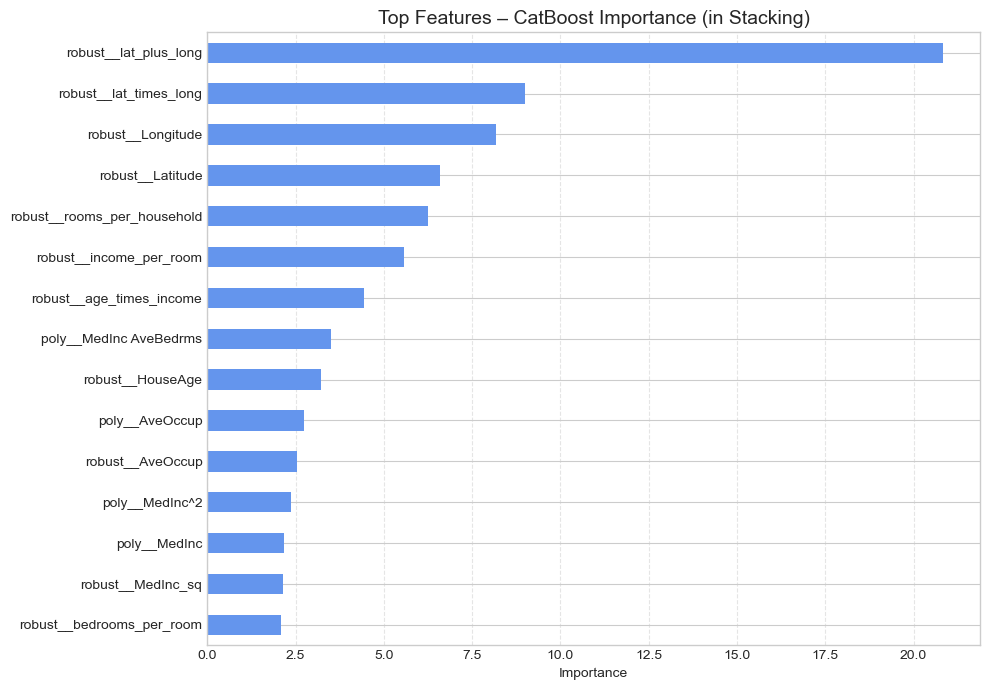

In [ ]:
from sklearn.linear_model import Ridge
best_cat_params = {
    'iterations': 1797,
    'learning_rate': 0.04446908901902836,
    'depth': 8,
    'l2_leaf_reg': 0.3597791042919832,
    'subsample': 0.8676047168693971,
    'colsample_bylevel': 0.9993612842160413,
    'random_seed': 42,
    'verbose': 200,
    'task_type': 'CPU',
}

best_lgb_params = {
    'n_estimators': 1695,
    'learning_rate': 0.017125018910542595,
    'max_depth': 12,
    'num_leaves': 126,
    'min_child_samples': 47,
    'subsample': 0.9534705451908634,
    'colsample_bytree': 0.6156107695262124,
    'reg_lambda': 2.7210019806425927,
    'reg_alpha': 3.2233684263404276,
    'random_state': 42,
    'n_jobs': -1,
    'verbosity': -1
}


cat_final = CatBoostRegressor(**best_cat_params)

lgb_final = LGBMRegressor(**best_lgb_params)

xgb_final = XGBRegressor(
    n_estimators=800,
    learning_rate=0.04,
    max_depth=6,
    subsample=0.85,
    colsample_bytree=0.80,
    reg_lambda=1.2,
    random_state=42,
    n_jobs=-1,
    # early_stopping_rounds=80,
)


estimators = [
    ('catboost', cat_final),
    ('lightgbm', lgb_final),
    ('xgboost',  xgb_final),
]

stacking_model = StackingRegressor(
    estimators=estimators,
    final_estimator=Ridge(alpha=0.8),
    cv=5,
    n_jobs=-1,
    passthrough=False,
    verbose=1
)

final_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('stacking', stacking_model)
])


print("\n" + "═"*65)
print("Evaluating FINAL Stacking Ensemble (CatBoost + LightGBM + XGBoost)")
print("═"*65)

kf = KFold(n_splits=5, shuffle=True, random_state=42)

rmse_scores = -cross_val_score(
    final_pipe,
    X_eng, y,
    cv=kf,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)

r2_scores = cross_val_score(
    final_pipe,
    X_eng, y,
    cv=kf,
    scoring='r2',
    n_jobs=-1
)

print(f"5-fold CV RMSE : {rmse_scores.mean():.5f} ± {rmse_scores.std():.5f}")
print(f"5-fold CV R²   : {r2_scores.mean():.5f} ± {r2_scores.std():.5f}")
print("═"*65)


print("\nTraining final stacking model on full training data...")
final_pipe.fit(X_eng, y)
print("Final model trained.")


print("\nExtracting feature importance from CatBoost (first base model)...")


fitted_catboost = final_pipe.named_steps['stacking'].estimators_[0]


feature_names = final_pipe.named_steps['preprocessor'].get_feature_names_out()


importances = fitted_catboost.get_feature_importance()
feat_imp_series = pd.Series(importances, index=feature_names)

# Top features
top_n = 15
top_features = feat_imp_series.sort_values(ascending=False).head(top_n)

# Plot
plt.figure(figsize=(10, 7))
top_features.plot.barh(color='cornflowerblue')
plt.title("Top Features – CatBoost Importance (in Stacking)", fontsize=14)
plt.xlabel("Importance")
plt.gca().invert_yaxis()
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


In [ ]:
cat_final = CatBoostRegressor(**best_cat_params)
lgb_final = LGBMRegressor(**best_lgb_params)

In [ ]:
from sklearn.linear_model import Ridge
# ─── 7. Stacking Ensemble (usually the strongest) ───
estimators = [
    ('cat', cat_final),
    ('lgb', lgb_final),
    ('xgb', XGBRegressor(n_estimators=700, learning_rate=0.05, max_depth=6, subsample=0.85,
                         colsample_bytree=0.8, random_state=42, n_jobs=-1))
]

stack = StackingRegressor(
    estimators=estimators,
    final_estimator=Ridge(alpha=0.5),
    cv=5,
    n_jobs=-1,
    passthrough=False
)

final_pipe = Pipeline([
    ('features', preprocessor),
    ('stack', stack)
])


FINAL STACKING ENSEMBLE (CatBoost + LightGBM + XGBoost)
5-fold CV RMSE: 0.4331 ± 0.0097
5-fold CV R²:   0.8590 ± 0.0070


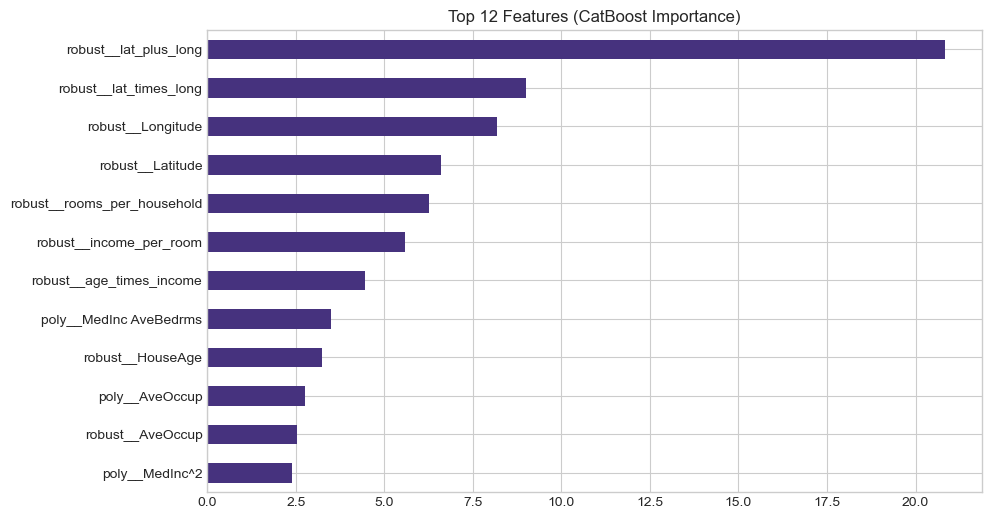

In [ ]:
# ─── 8. Final Evaluation ───
from sklearn.model_selection import KFold, cross_val_score
kf = KFold(n_splits=5, shuffle=True, random_state=42)
rmse_scores = -cross_val_score(final_pipe, X_eng, y, cv=kf, scoring='neg_root_mean_squared_error')
r2_scores   = cross_val_score(final_pipe, X_eng, y, cv=kf, scoring='r2')

print("\n" + "="*50)
print("FINAL STACKING ENSEMBLE (CatBoost + LightGBM + XGBoost)")
print(f"5-fold CV RMSE: {rmse_scores.mean():.4f} \u00B1 {rmse_scores.std():.4f}")
print(f"5-fold CV R\u00B2:   {r2_scores.mean():.4f} \u00B1 {r2_scores.std():.4f}")
print("="*50)

# Fit final model on full data
final_pipe.fit(X_eng, y)

# Feature importance example (from CatBoost)
cat_model = final_pipe.named_steps['stack'].estimators_[0]
importances = pd.Series(cat_model.get_feature_importance(),
                        index=final_pipe.named_steps['features'].get_feature_names_out())
top_features = importances.sort_values(ascending=False).head(12)

plt.figure(figsize=(10, 6))
top_features.plot.barh(title="Top 12 Features (CatBoost Importance)")
plt.gca().invert_yaxis()
plt.show()

In [ ]:
# 9. Final cross-validation check
rmse_scores = -cross_val_score(final_pipe, X_eng, y, cv=kf, scoring='neg_root_mean_squared_error')
r2_scores   = cross_val_score(final_pipe, X_eng, y, cv=kf, scoring='r2')

print(f"5-fold CV RMSE: {rmse_scores.mean():.4f} \u00B1 {rmse_scores.std():.4f}")
print(f"5-fold CV R\u00B2:   {r2_scores.mean():.4f} \u00B1 {r2_scores.std():.4f}")

5-fold CV RMSE: 0.4331 ± 0.0097
5-fold CV R²:   0.8590 ± 0.0070


In [ ]:
# 10. Fit on all data + show which features mattered most
final_pipe.fit(X_eng, y)

cat_model = final_pipe.named_steps['stack'].estimators_[0]
importances = pd.Series(cat_model.get_feature_importance(),
                        index=final_pipe.named_steps['features'].get_feature_names_out())

In [ ]:
print(importances)

poly__MedInc                         2.162645
poly__AveRooms                       0.450805
poly__AveBedrms                      0.867971
poly__Population                     0.454754
poly__AveOccup                       2.746540
poly__MedInc^2                       2.384646
poly__MedInc AveRooms                1.112058
poly__MedInc AveBedrms               3.495904
poly__MedInc Population              0.960992
poly__MedInc AveOccup                0.987838
poly__AveRooms^2                     0.248810
poly__AveRooms AveBedrms             1.014056
poly__AveRooms Population            0.690053
poly__AveRooms AveOccup              1.166379
poly__AveBedrms^2                    0.701909
poly__AveBedrms Population           0.646110
poly__AveBedrms AveOccup             1.594137
poly__Population^2                   0.194080
poly__Population AveOccup            0.774209
poly__AveOccup^2                     1.517874
robust__MedInc                       1.052626
robust__HouseAge                  

# Executive Summary

1. Developed an end-to-end machine learning pipeline for house price prediction using the California Housing dataset (20,640 samples).

2. Performed extensive exploratory data analysis, revealing strong geographic clustering and identifying Median Income as the most influential predictor.

3. Applied advanced feature engineering including ratio features, log transformations, geographic interaction features, polynomial terms, and economic interaction variables to capture nonlinear relationships.

4. Implemented a robust preprocessing pipeline using ColumnTransformer, PolynomialFeatures, and RobustScaler to handle outliers and feature scaling.

5. Built an ensemble stacking model combining CatBoost, LightGBM, and XGBoost as base learners with Ridge regression as the meta-learner.

6. Hyperparameters were optimized using Optuna-based tuning, and model performance was evaluated using 5-fold cross-validation.

7. The final model achieved R² = 0.859 ± 0.007 and RMSE = 0.433 ± 0.009, indicating strong predictive accuracy and good generalization capability.

8. Feature importance analysis showed that geographic interaction features and income-related variables were the dominant drivers of house price prediction.

9. The study demonstrates that combining domain-driven feature engineering with advanced ensemble learning significantly improves regression performance.